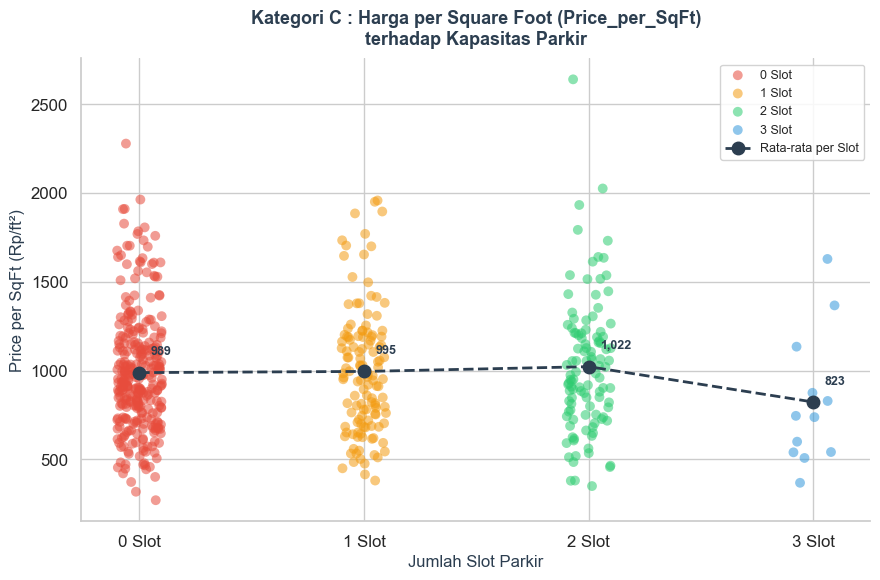

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Load dataset ────────────────────────────────────────────
df = pd.read_csv("Kelas C_Housing.csv")

# ── Style ──────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
ACCENT = "#2C3E50"

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor('#FFFFFF')

df['Price_per_SqFt'] = df['price'] / df['area']

parking_colors = {0: '#E74C3C', 1: '#F39C12', 2: '#2ECC71', 3: '#3498DB'}
parking_labels = {0: '0 Slot', 1: '1 Slot', 2: '2 Slot', 3: '3 Slot'}

for park_val, grp in df.groupby('parking'):
    ax.scatter(grp['parking'] + np.random.uniform(-0.1, 0.1, len(grp)),
               grp['Price_per_SqFt'],
               color=parking_colors[park_val],
               alpha=0.55, s=50, edgecolors='none',
               label=parking_labels[park_val])

# Garis rata-rata per kelompok parkir
means = df.groupby('parking')['Price_per_SqFt'].mean()
ax.plot(means.index, means.values, 'o--',
        color=ACCENT, linewidth=2, markersize=9,
        zorder=5, label='Rata-rata per Slot')
for x_val, y_val in zip(means.index, means.values):
    ax.text(x_val + 0.05, y_val + 100,
            f'{y_val:,.0f}', fontsize=9, color=ACCENT, fontweight='bold')

ax.set_xlabel('Jumlah Slot Parkir', fontsize=12, color=ACCENT)
ax.set_ylabel('Price per SqFt (Rp/ft²)', fontsize=12, color=ACCENT)
ax.set_title('Kategori C : Harga per Square Foot (Price_per_SqFt)\nterhadap Kapasitas Parkir',
             fontsize=13, fontweight='bold', color=ACCENT, pad=10)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0 Slot', '1 Slot', '2 Slot', '3 Slot'])
ax.legend(fontsize=9, framealpha=0.85)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()